In [2]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from pathlib import Path
import pycwt as wavelet
from scipy.interpolate import interp2d
from scipy.ndimage import gaussian_filter

# Set plot style
plt.style.use('default')
%matplotlib inline

In [ ]:
CASE_DIR = 'experiments/experiment_5/outputs/azimuthal_coverage_analysis/case_06_NE_ESE_az060-120'

RECEIVER_DISTANCE_KM = 150

CCF_XLIM = 100  

FTAN_PARAMS = {
    'fmin': 0.05,      
    'fmax': 1.0,       
    'vmin': 0.5,       
    'vmax': 4.5,       
    'dj': 1/24,        
    'sigma': 0.15,     
    'amp_threshold': 0.7,  
    'min_period': 3.0      
}

print(f"  Case directory: {CASE_DIR}")
print(f"  Receiver distance: {RECEIVER_DISTANCE_KM} km")
print(f"  CCF zoom: ±{CCF_XLIM} s")
print(f"  FTAN: {FTAN_PARAMS['fmin']}-{FTAN_PARAMS['fmax']} Hz, {FTAN_PARAMS['vmin']}-{FTAN_PARAMS['vmax']} km/s")

  Case directory: experiments/experiment_5/outputs/azimuthal_coverage_analysis/case_06_NE_ESE_az060-120
  Receiver distance: 150 km
  CCF zoom: ±100 s
  FTAN: 0.05-1.0 Hz, 0.5-4.5 km/s


In [30]:
case_path = Path(CASE_DIR)

if not case_path.exists():
    raise FileNotFoundError(f"Case directory not found: {CASE_DIR}")

r1_data = np.loadtxt(case_path / 'stacked_r1_waveform.txt')
r2_data = np.loadtxt(case_path / 'stacked_r2_waveform.txt')

ccf_data = np.loadtxt(case_path / 'stacked_time_ccf.txt')

coherence_data = np.loadtxt(case_path / 'stacked_coherence_freq.txt')

sources_df = pd.read_csv(case_path / 'all_sources.csv')

sregn_file = case_path / 'SREGN.ASC'
if sregn_file.exists():
    sregn_data = np.loadtxt(sregn_file, skiprows=1)
    mode0_mask = sregn_data[:, 0] == 0
    theoretical_period = sregn_data[mode0_mask, 2]     
    theoretical_group_vel = sregn_data[mode0_mask, 5]  
    print(f"   SREGN.ASC loaded: {len(theoretical_period)} points (mode 0 only)")
else:
    print("   Warning: SREGN.ASC not found, theoretical dispersion unavailable")
    theoretical_period = None
    theoretical_group_vel = None


print(f"  R1 waveform: {len(r1_data)} samples")
print(f"  R2 waveform: {len(r2_data)} samples")
print(f"  CCF: {len(ccf_data)} lags")
print(f"  Coherence: {len(coherence_data)} frequencies")
print(f"  Sources: {len(sources_df):,} locations")

   SREGN.ASC loaded: 256 points (mode 0 only)
  R1 waveform: 7199 samples
  R2 waveform: 7199 samples
  CCF: 7199 lags
  Coherence: 3599 frequencies
  Sources: 300,000 locations


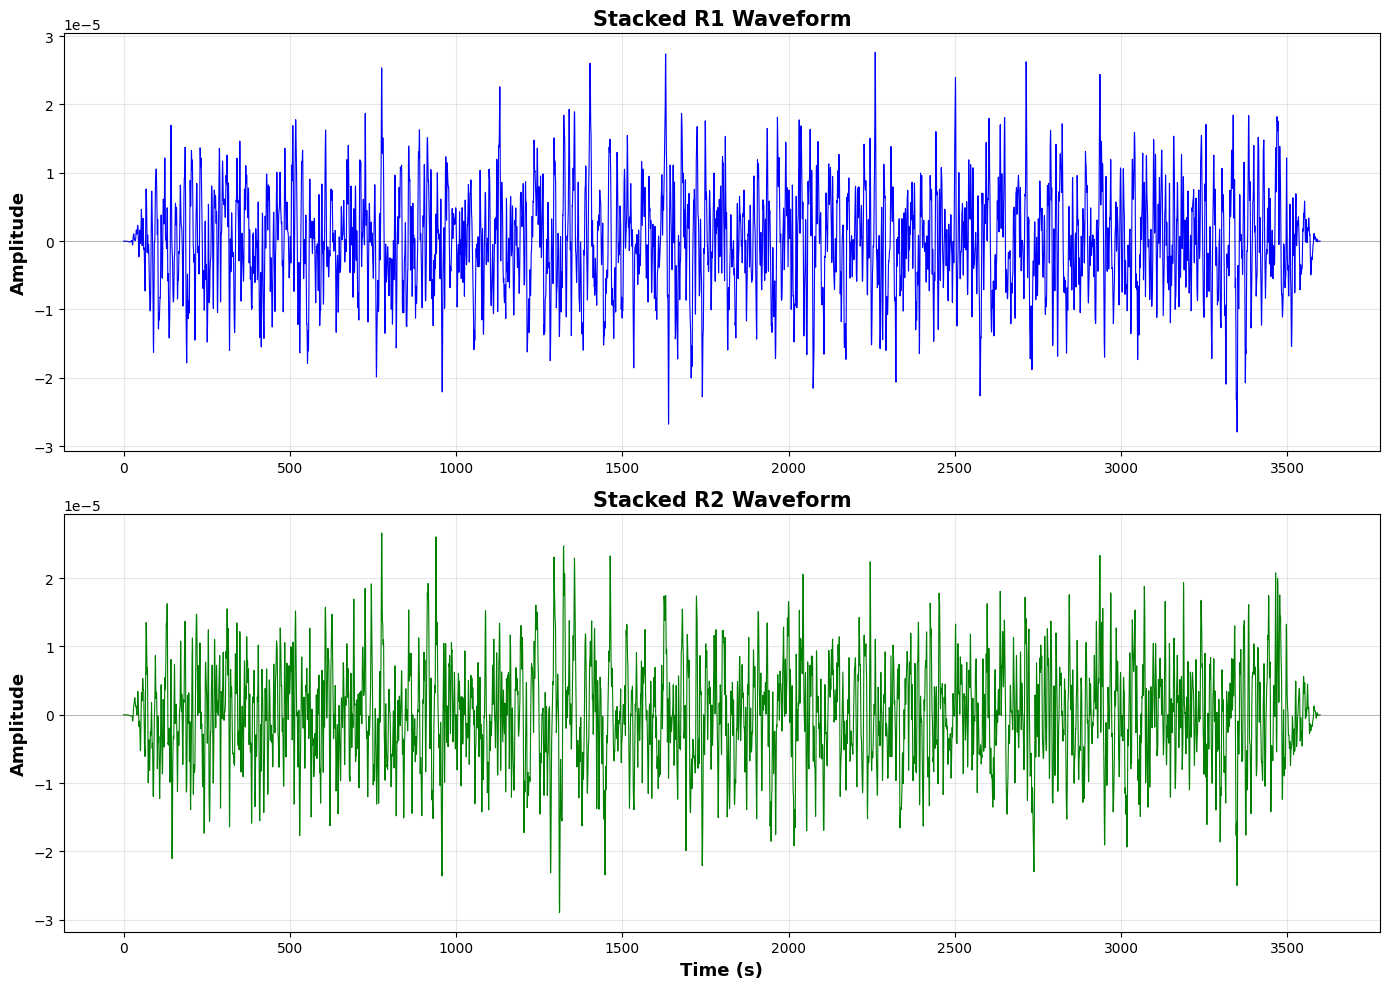

In [31]:
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 10))

ax1.plot(r1_data[:, 0], r1_data[:, 1], 'b-', linewidth=0.8)
ax1.set_ylabel('Amplitude', fontsize=13, fontweight='bold')
ax1.set_title('Stacked R1 Waveform', fontsize=15, fontweight='bold')
ax1.grid(True, alpha=0.3)
ax1.axhline(0, color='k', linestyle='-', linewidth=0.5, alpha=0.3)

ax2.plot(r2_data[:, 0], r2_data[:, 1], 'g-', linewidth=0.8)
ax2.set_xlabel('Time (s)', fontsize=13, fontweight='bold')
ax2.set_ylabel('Amplitude', fontsize=13, fontweight='bold')
ax2.set_title('Stacked R2 Waveform', fontsize=15, fontweight='bold')
ax2.grid(True, alpha=0.3)
ax2.axhline(0, color='k', linestyle='-', linewidth=0.5, alpha=0.3)

plt.tight_layout()
plt.show()

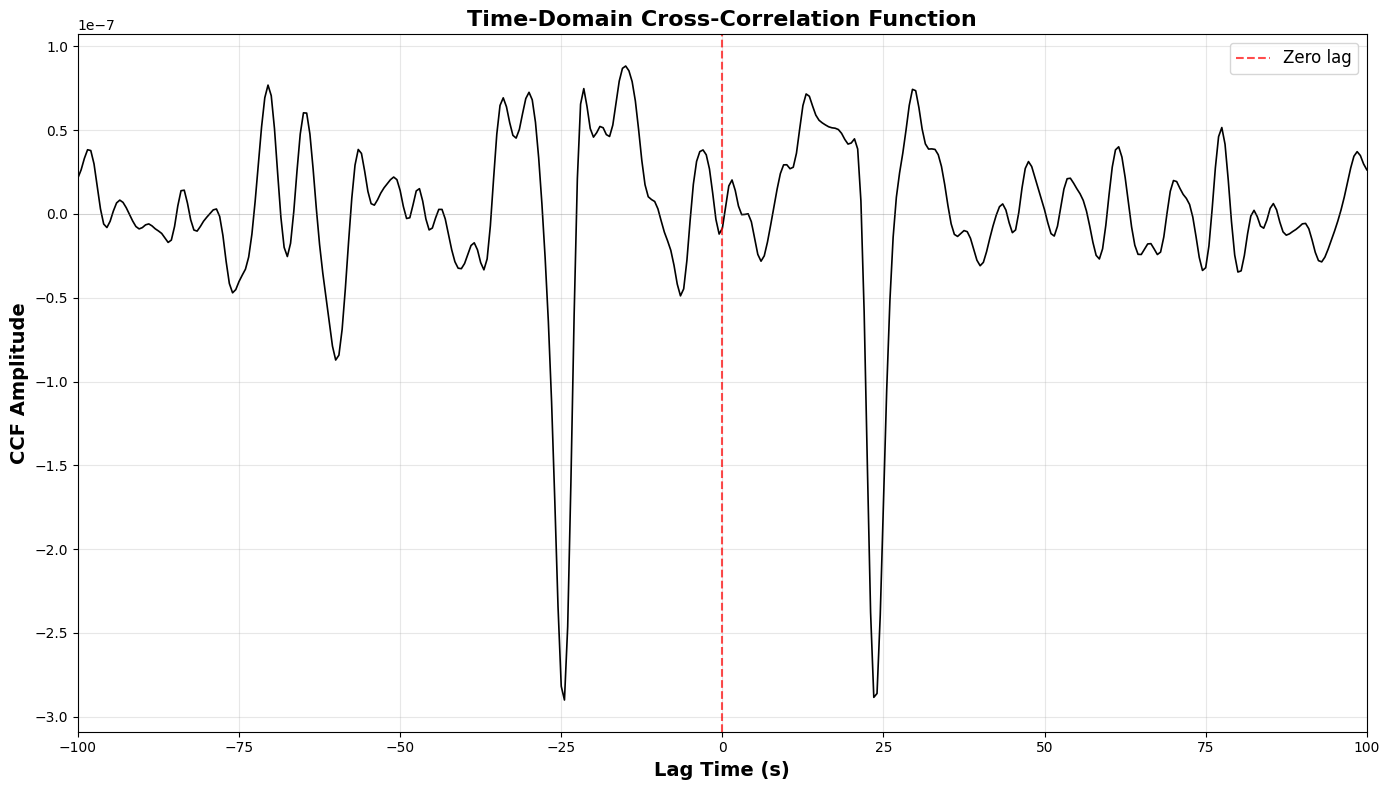

  Peak amplitude: -2.90e-07 at lag -24.5 s


In [32]:
fig, ax = plt.subplots(figsize=(14, 8))

mask = np.abs(ccf_data[:, 0]) <= CCF_XLIM
ax.plot(ccf_data[mask, 0], ccf_data[mask, 1], 'k-', linewidth=1.2)

ax.axvline(0, color='red', linestyle='--', linewidth=1.5, alpha=0.7, label='Zero lag')
ax.axhline(0, color='gray', linestyle='-', linewidth=0.5, alpha=0.3)

ax.set_xlabel('Lag Time (s)', fontsize=14, fontweight='bold')
ax.set_ylabel('CCF Amplitude', fontsize=14, fontweight='bold')
ax.set_title('Time-Domain Cross-Correlation Function', fontsize=16, fontweight='bold')
ax.grid(True, alpha=0.3)
ax.legend(fontsize=12)
ax.set_xlim([-CCF_XLIM, CCF_XLIM])

plt.tight_layout()
plt.show()

peak_idx = np.argmax(np.abs(ccf_data[:, 1]))
peak_lag = ccf_data[peak_idx, 0]
peak_amp = ccf_data[peak_idx, 1]

print(f"  Peak amplitude: {peak_amp:.2e} at lag {peak_lag:.1f} s")

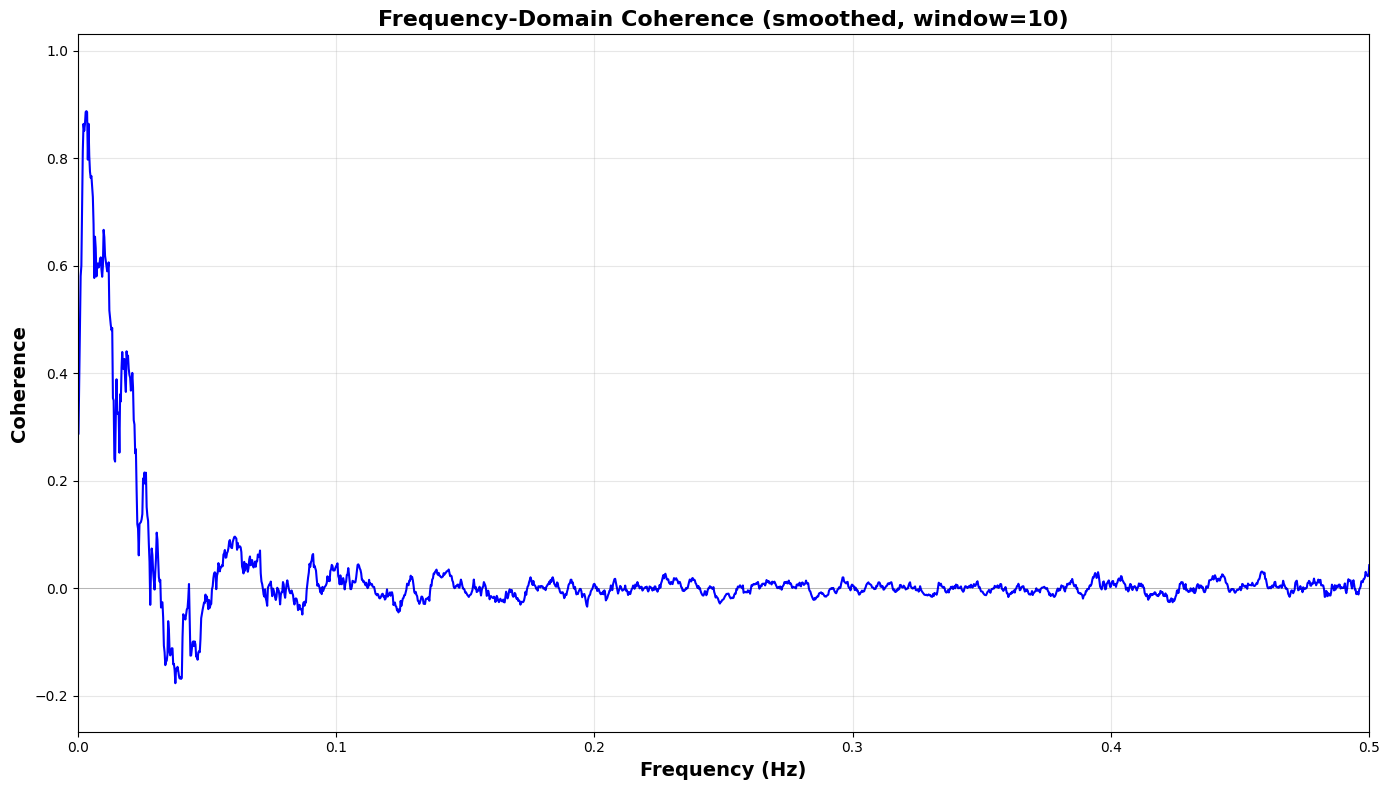

  Average coherence (0.05-0.33 Hz): 0.004
  Maximum coherence: 0.972


In [33]:
fig, ax = plt.subplots(figsize=(14, 8))

ax.plot(coherence_data[:, 0], coherence_data[:, 1], 'b-', linewidth=1.5)

ax.set_xlabel('Frequency (Hz)', fontsize=14, fontweight='bold')
ax.set_ylabel('Coherence', fontsize=14, fontweight='bold')
ax.set_title('Frequency-Domain Coherence (smoothed, window=10)', fontsize=16, fontweight='bold')
ax.grid(True, alpha=0.3)
ax.set_xlim([0, 0.5])
ax.axhline(0, color='k', linestyle='-', linewidth=0.5, alpha=0.3)

plt.tight_layout()
plt.show()

microseism_mask = (coherence_data[:, 0] >= 0.05) & (coherence_data[:, 0] <= 0.33)
avg_coherence = np.mean(coherence_data[microseism_mask, 1])
max_coherence = np.max(coherence_data[:, 1])

print(f"  Average coherence (0.05-0.33 Hz): {avg_coherence:.3f}")
print(f"  Maximum coherence: {max_coherence:.3f}")

In [34]:
class FTAN_NoisePy:
    
    def __init__(self, ccf_data, distance_km, theoretical_period=None, theoretical_group_vel=None):
        self.distance_km = distance_km
        self.dt = 0.5
        
        self.lags = ccf_data[:, 0]
        self.ccf = ccf_data[:, 1]
        
        self.theory_periods = theoretical_period
        self.theory_gvel = theoretical_group_vel

    def compute_ftan(self, fmin=0.05, fmax=1.0, vmin=0.5, vmax=4.5):
        print(f"  Computing FTAN: freq {fmin}-{fmax} Hz, vel {vmin}-{vmax} km/s")
        
        npts = len(self.ccf)
        indx = npts // 2
        
        data = 0.5 * self.ccf[indx:] + 0.5 * np.flip(self.ccf[:indx + 1], axis=0)
        
        pt1 = int(self.distance_km / vmax / self.dt)
        pt2 = int(self.distance_km / vmin / self.dt)
        
        if pt1 == 0:
            pt1 = 10
        if pt2 > (npts // 2):
            pt2 = npts // 2
            
        indx = np.arange(pt1, pt2)
        tvec = indx * self.dt
        data = data[indx]
        
        print(f"  Trimmed data: {len(data)} points, time range {tvec[0]:.1f}-{tvec[-1]:.1f}s")
        
        import pycwt
        
        dj = 1/24      
        s0 = -1        
        J = -1         
        wvn = 'morlet' 
        
        print(f"  Running pycwt.cwt with dj={dj}, s0={s0}, J={J}, wavelet={wvn}")
        cwt, sj, freq, coi, _, _ = pycwt.cwt(data, self.dt, dj, s0, J, wvn)
        
        print(f"  CWT complete: {len(freq)} frequencies from {freq.min():.3f} to {freq.max():.3f} Hz")
        
        if (fmax > np.max(freq)) or (fmax <= fmin):
            raise ValueError(f"Frequency out of limits! freq range: {freq.min():.3f}-{freq.max():.3f} Hz")
        
        freq_ind = np.where((freq >= fmin) & (freq <= fmax))[0]
        cwt = cwt[freq_ind]
        freq = freq[freq_ind]
        
        print(f"  Filtered to {len(freq)} frequencies: {freq.min():.3f}-{freq.max():.3f} Hz")
        
        period = 1 / freq
        rcwt = np.abs(cwt) ** 2  # Power spectrum
        
        print(f"  Period range: {period.min():.1f}-{period.max():.1f}s")
        
        per = np.arange(int(1/fmax), int(1/fmin), 0.25)  
        vel = np.arange(vmin, vmax, 0.01)                
        
        print(f"  Interpolation grids: {len(per)} periods, {len(vel)} velocities")
        velocity_data = self.distance_km / tvec
        
        from scipy.interpolate import interp2d
        fc = interp2d(velocity_data, period, rcwt, kind='linear')
        rcwt_new = fc(vel, per)
        
        for ii in range(len(per)):
            max_val = np.max(rcwt_new[ii])
            if max_val > 0:
                rcwt_new[ii] /= max_val
        
        from scipy.ndimage import gaussian_filter1d
        sigma = 0.15 
        for j in range(len(vel)):
            rcwt_new[:, j] = gaussian_filter1d(rcwt_new[:, j], sigma=sigma)
        
        # Store results
        self.periods = per
        self.velocities = vel
        self.ftan_amp = rcwt_new
        self.tvec = tvec
        self.data = data
        
        print(f"  FTAN complete: {rcwt_new.shape}")
        
        return per, vel, rcwt_new

    def extract_dispersion(self, amp_threshold=0.7, min_period=3.0):
        nper = []
        gv = []
        
        for ii in range(len(self.periods)):
            if self.periods[ii] < min_period:
                continue
            
            max_idx = np.argmax(self.ftan_amp[ii, :])
            max_amp = self.ftan_amp[ii, max_idx]
            
            if max_amp > amp_threshold:
                nper.append(self.periods[ii])
                gv.append(self.velocities[max_idx])
        
        self.periods_picked = np.array(nper)
        self.group_velocities = np.array(gv)
        
        print(f"  Extracted {len(nper)} dispersion points (periods ≥{min_period}s, amp >{amp_threshold})")
        
        # Calculate RMS error
        if len(self.periods_picked) > 0 and self.theory_periods is not None:
            theory_at_picked = np.interp(self.periods_picked, self.theory_periods, self.theory_gvel)
            misfit = np.sqrt(np.mean((self.group_velocities - theory_at_picked)**2))
            rel_misfit = misfit / np.mean(theory_at_picked) * 100
            self.rms_error = rel_misfit
        else:
            self.rms_error = 999.9
        
        print(f"  RMS error: {self.rms_error:.1f}%")
        
        return self.periods_picked, self.group_velocities

    def run_full_analysis(self, fmin=0.05, fmax=1.0, vmin=0.5, vmax=4.5, 
                         amp_threshold=0.7, min_period=3.0):

        
        self.compute_ftan(fmin=fmin, fmax=fmax, vmin=vmin, vmax=vmax)
        self.extract_dispersion(amp_threshold=amp_threshold, min_period=min_period)
        


In [35]:
import warnings
warnings.filterwarnings('ignore')
ftan = FTAN_NoisePy(
    ccf_data,
    distance_km=RECEIVER_DISTANCE_KM,
    theoretical_period=theoretical_period,
    theoretical_group_vel=theoretical_group_vel
)

ftan.run_full_analysis(
    fmin=FTAN_PARAMS['fmin'],
    fmax=FTAN_PARAMS['fmax'],
    vmin=FTAN_PARAMS['vmin'],
    vmax=FTAN_PARAMS['vmax'],
    amp_threshold=FTAN_PARAMS['amp_threshold'],
    min_period=FTAN_PARAMS['min_period']
)

print(f"  Extracted: {len(ftan.periods_picked)} points")
print(f"  RMS error: {ftan.rms_error:.2f}%")

  Computing FTAN: freq 0.05-1.0 Hz, vel 0.5-4.5 km/s
  Trimmed data: 534 points, time range 33.0-299.5s
  Running pycwt.cwt with dj=0.041666666666666664, s0=-1, J=-1, wavelet=morlet
  CWT complete: 196 frequencies from 0.004 to 1.000 Hz
  Filtered to 104 frequencies: 0.051-1.000 Hz
  Period range: 1.0-19.6s
  Interpolation grids: 76 periods, 400 velocities
  FTAN complete: (76, 400)
  Extracted 68 dispersion points (periods ≥3.0s, amp >0.7)
  RMS error: 59.3%
  Extracted: 68 points
  RMS error: 59.27%


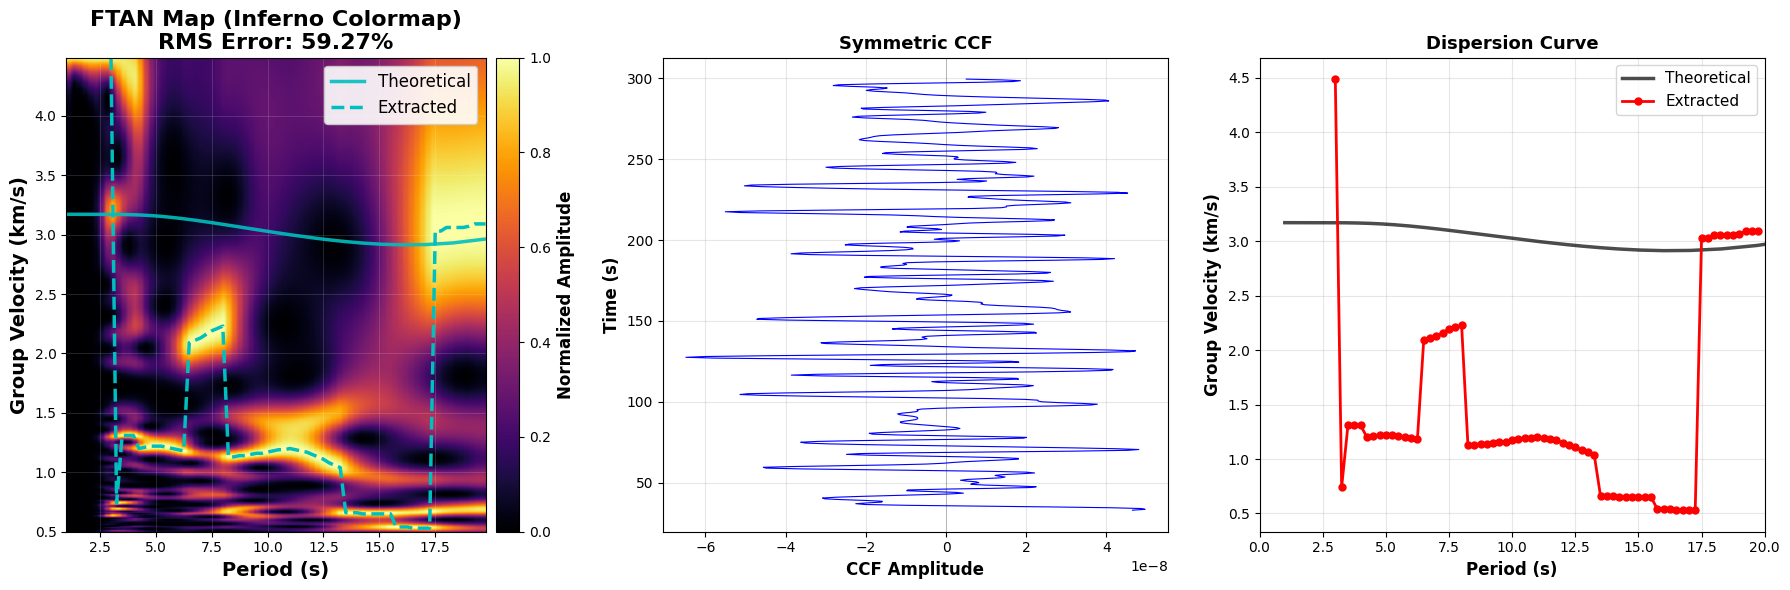

In [36]:
fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(18, 6))

im = ax1.imshow(np.transpose(ftan.ftan_amp), 
               cmap='inferno',  
               extent=[ftan.periods[0], ftan.periods[-1], 
                      ftan.velocities[0], ftan.velocities[-1]],
               aspect='auto', 
               origin='lower',
               vmin=0, vmax=1)

if ftan.theory_periods is not None:
    theory_mask = (ftan.theory_periods >= ftan.periods[0]) & (ftan.theory_periods <= ftan.periods[-1])
    theory_mask &= (ftan.theory_gvel >= ftan.velocities[0]) & (ftan.theory_gvel <= ftan.velocities[-1])
    ax1.plot(ftan.theory_periods[theory_mask], ftan.theory_gvel[theory_mask],
            'c-', linewidth=2.5, label='Theoretical', alpha=0.9)

if len(ftan.periods_picked) > 0:
    ax1.plot(ftan.periods_picked, ftan.group_velocities,
            'c--', linewidth=2.5, label='Extracted', alpha=1.0)

ax1.set_xlabel('Period (s)', fontsize=14, fontweight='bold')
ax1.set_ylabel('Group Velocity (km/s)', fontsize=14, fontweight='bold')
ax1.set_title(f'FTAN Map (Inferno Colormap)\nRMS Error: {ftan.rms_error:.2f}%', 
              fontsize=16, fontweight='bold')
ax1.legend(loc='upper right', fontsize=12, framealpha=0.9)
ax1.grid(True, alpha=0.2, color='white', linewidth=0.5)

cbar = plt.colorbar(im, ax=ax1, pad=0.02)
cbar.set_label('Normalized Amplitude', fontsize=12, fontweight='bold')

ax2.plot(ftan.data, ftan.tvec, 'b-', linewidth=0.8)
ax2.set_ylabel('Time (s)', fontsize=12, fontweight='bold')
ax2.set_xlabel('CCF Amplitude', fontsize=12, fontweight='bold')
ax2.set_title('Symmetric CCF', fontsize=13, fontweight='bold')
ax2.grid(True, alpha=0.3)
ax2.axvline(0, color='k', linestyle='-', linewidth=0.5, alpha=0.3)

if ftan.theory_periods is not None:
    ax3.plot(ftan.theory_periods, ftan.theory_gvel, 'k-', linewidth=2.5, 
            label='Theoretical', alpha=0.7)

if len(ftan.periods_picked) > 0:
    ax3.plot(ftan.periods_picked, ftan.group_velocities, 'ro-', 
            linewidth=2, markersize=5, label='Extracted')

ax3.set_xlabel('Period (s)', fontsize=12, fontweight='bold')
ax3.set_ylabel('Group Velocity (km/s)', fontsize=12, fontweight='bold')
ax3.set_title('Dispersion Curve', fontsize=13, fontweight='bold')
ax3.grid(True, alpha=0.3)
ax3.legend(fontsize=11)
ax3.set_xlim([0, 20])

plt.tight_layout()
plt.show()

In [ ]:
if theoretical_period is not None and len(ftan.extracted_period) > 0:
    from scipy.interpolate import interp1d
    
    period_min = max(ftan.extracted_period.min(), theoretical_period.min())
    period_max = min(ftan.extracted_period.max(), theoretical_period.max())
    
    common_mask = (ftan.extracted_period >= period_min) & (ftan.extracted_period <= period_max)
    extracted_per_common = ftan.extracted_period[common_mask]
    extracted_vel_common = ftan.extracted_velocity[common_mask]
    
    if len(extracted_per_common) > 0:
        f_interp = interp1d(theoretical_period, theoretical_group_vel, kind='linear', 
                           bounds_error=False, fill_value='extrapolate')
        theoretical_vel_at_extracted = f_interp(extracted_per_common)
        
        velocity_errors = extracted_vel_common - theoretical_vel_at_extracted
        rms_error = np.sqrt(np.mean(velocity_errors**2))
        mean_velocity = np.mean(theoretical_vel_at_extracted)
        rms_error_percent = (rms_error / mean_velocity) * 100
        
        mae = np.mean(np.abs(velocity_errors))
        mae_percent = (mae / mean_velocity) * 100
        
        print(f"  Common period range: {period_min:.1f} - {period_max:.1f} s")
        print(f"  Number of points: {len(extracted_per_common)}")
        print(f"  Mean theoretical velocity: {mean_velocity:.3f} km/s")
        print(f"  RMS error: {rms_error:.4f} km/s ({rms_error_percent:.2f}%)")
        print(f"  Mean absolute error: {mae:.4f} km/s ({mae_percent:.2f}%)")
        print(f"  Max error: {np.max(np.abs(velocity_errors)):.4f} km/s")
        print(f"  Min error: {np.min(np.abs(velocity_errors)):.4f} km/s")
        fig, ax = plt.subplots(figsize=(12, 6))
        ax.plot(extracted_per_common, velocity_errors, 'ko-', markersize=6, linewidth=1.5)
        ax.axhline(0, color='red', linestyle='--', linewidth=2, alpha=0.7)
        ax.fill_between(extracted_per_common, -rms_error, rms_error, alpha=0.2, color='gray', 
                        label=f'±RMS ({rms_error_percent:.2f}%)')
        
        ax.set_xlabel('Period (s)', fontsize=14, fontweight='bold')
        ax.set_ylabel('Velocity Error (km/s)', fontsize=14, fontweight='bold')
        ax.set_title('Dispersion Residuals (Extracted - Theoretical)', fontsize=16, fontweight='bold')
        ax.legend(fontsize=12)
        ax.grid(True, alpha=0.3)
        
        plt.tight_layout()
        plt.show()
        
    else:
        print("No common period range for error calculation")
else:
    print("Cannot calculate RMS error: missing theoretical or extracted dispersion")